## Loading initial dataframe

Load data into pandas dataframe from parquet file

In [1]:
import pyarrow.parquet as pq

table = pq.read_table("../data/phaenomena_student_data.parquet")
df = table.to_pandas()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104224 entries, 0 to 104223
Data columns (total 30 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   filename      104224 non-null  str    
 1   dataset       104224 non-null  str    
 2   label         104224 non-null  str    
 3   ts            104224 non-null  str    
 4   hour          104224 non-null  int32  
 5   date          104224 non-null  object 
 6   quality       104224 non-null  str    
 7   dead_flag     104224 non-null  bool   
 8   suspect_flag  104224 non-null  bool   
 9   fs            104224 non-null  int64  
 10  n_samples     104224 non-null  int64  
 11  duration_s    104224 non-null  float64
 12  mean          104224 non-null  float64
 13  median        104224 non-null  float64
 14  std           104224 non-null  float64
 15  iqr           104224 non-null  float64
 16  min           104224 non-null  float64
 17  max           104224 non-null  float64
 18  range         1

Copy all emotion training data from the dataset and inspect for columns with only one value

In [2]:
df_em = df[df["dataset"] == "emotion_training_data"].copy()
df_em.nunique()

filename        41086
dataset             1
label               2
ts              41086
hour               24
date               22
quality             5
dead_flag           2
suspect_flag        2
fs                  1
n_samples           1
duration_s          1
mean            37848
median          23328
std             37870
iqr             13459
min             17819
max             17502
range           14176
rms             37870
zcr               775
sat_pos_frac       60
sat_neg_frac        1
const_flag          2
bp_0_1          37931
bp_1_5          37931
bp_5_15         37931
bp_15_30        37931
bp_30_50        37931
total_power     37931
dtype: int64

Drop everything that only has unique values as well as every time column -> Unnecessary for training

In [3]:
# Drop indexing columns
df_em.drop(columns=["dataset", "filename"], inplace=True)
# Drop columns with only one unique value (useless for ML)
df_em.drop(columns=["fs", "n_samples", "duration_s", "sat_neg_frac"], inplace=True)
# Drop time columns (not relevant for classification task)
df_em.drop(columns=["ts", "hour", "date"], inplace=True)
df_em.info()

<class 'pandas.DataFrame'>
RangeIndex: 41086 entries, 0 to 41085
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   label         41086 non-null  str    
 1   quality       41086 non-null  str    
 2   dead_flag     41086 non-null  bool   
 3   suspect_flag  41086 non-null  bool   
 4   mean          41086 non-null  float64
 5   median        41086 non-null  float64
 6   std           41086 non-null  float64
 7   iqr           41086 non-null  float64
 8   min           41086 non-null  float64
 9   max           41086 non-null  float64
 10  range         41086 non-null  float64
 11  rms           41086 non-null  float64
 12  zcr           41086 non-null  float64
 13  sat_pos_frac  41086 non-null  float64
 14  const_flag    41086 non-null  bool   
 15  bp_0_1        41086 non-null  float64
 16  bp_1_5        41086 non-null  float64
 17  bp_5_15       41086 non-null  float64
 18  bp_15_30      41086 non-null  float64

Encode boolean and string values to integers

In [4]:
# Map labels to binary values
mapping_label = {'emotion_positive': 1, 'emotion_negative': 0}
df_em[['label']] = df_em[['label']].replace(mapping_label)

# Map quality to integer values
mapping_quality = {'ok' : 0,
                   'suspect_lowamp' : 1,
                   'suspect_clipped' : 2,
                   'dead_flat' : 3,
                   'dead_saturated' : 4}
df_em[['quality']] = df_em[['quality']].replace(mapping_quality)

df_em[['dead_flag', 'suspect_flag', 'const_flag']] = df_em[['dead_flag', 'suspect_flag', 'const_flag']].astype(int)

## Visualizations

### Correlation matrix

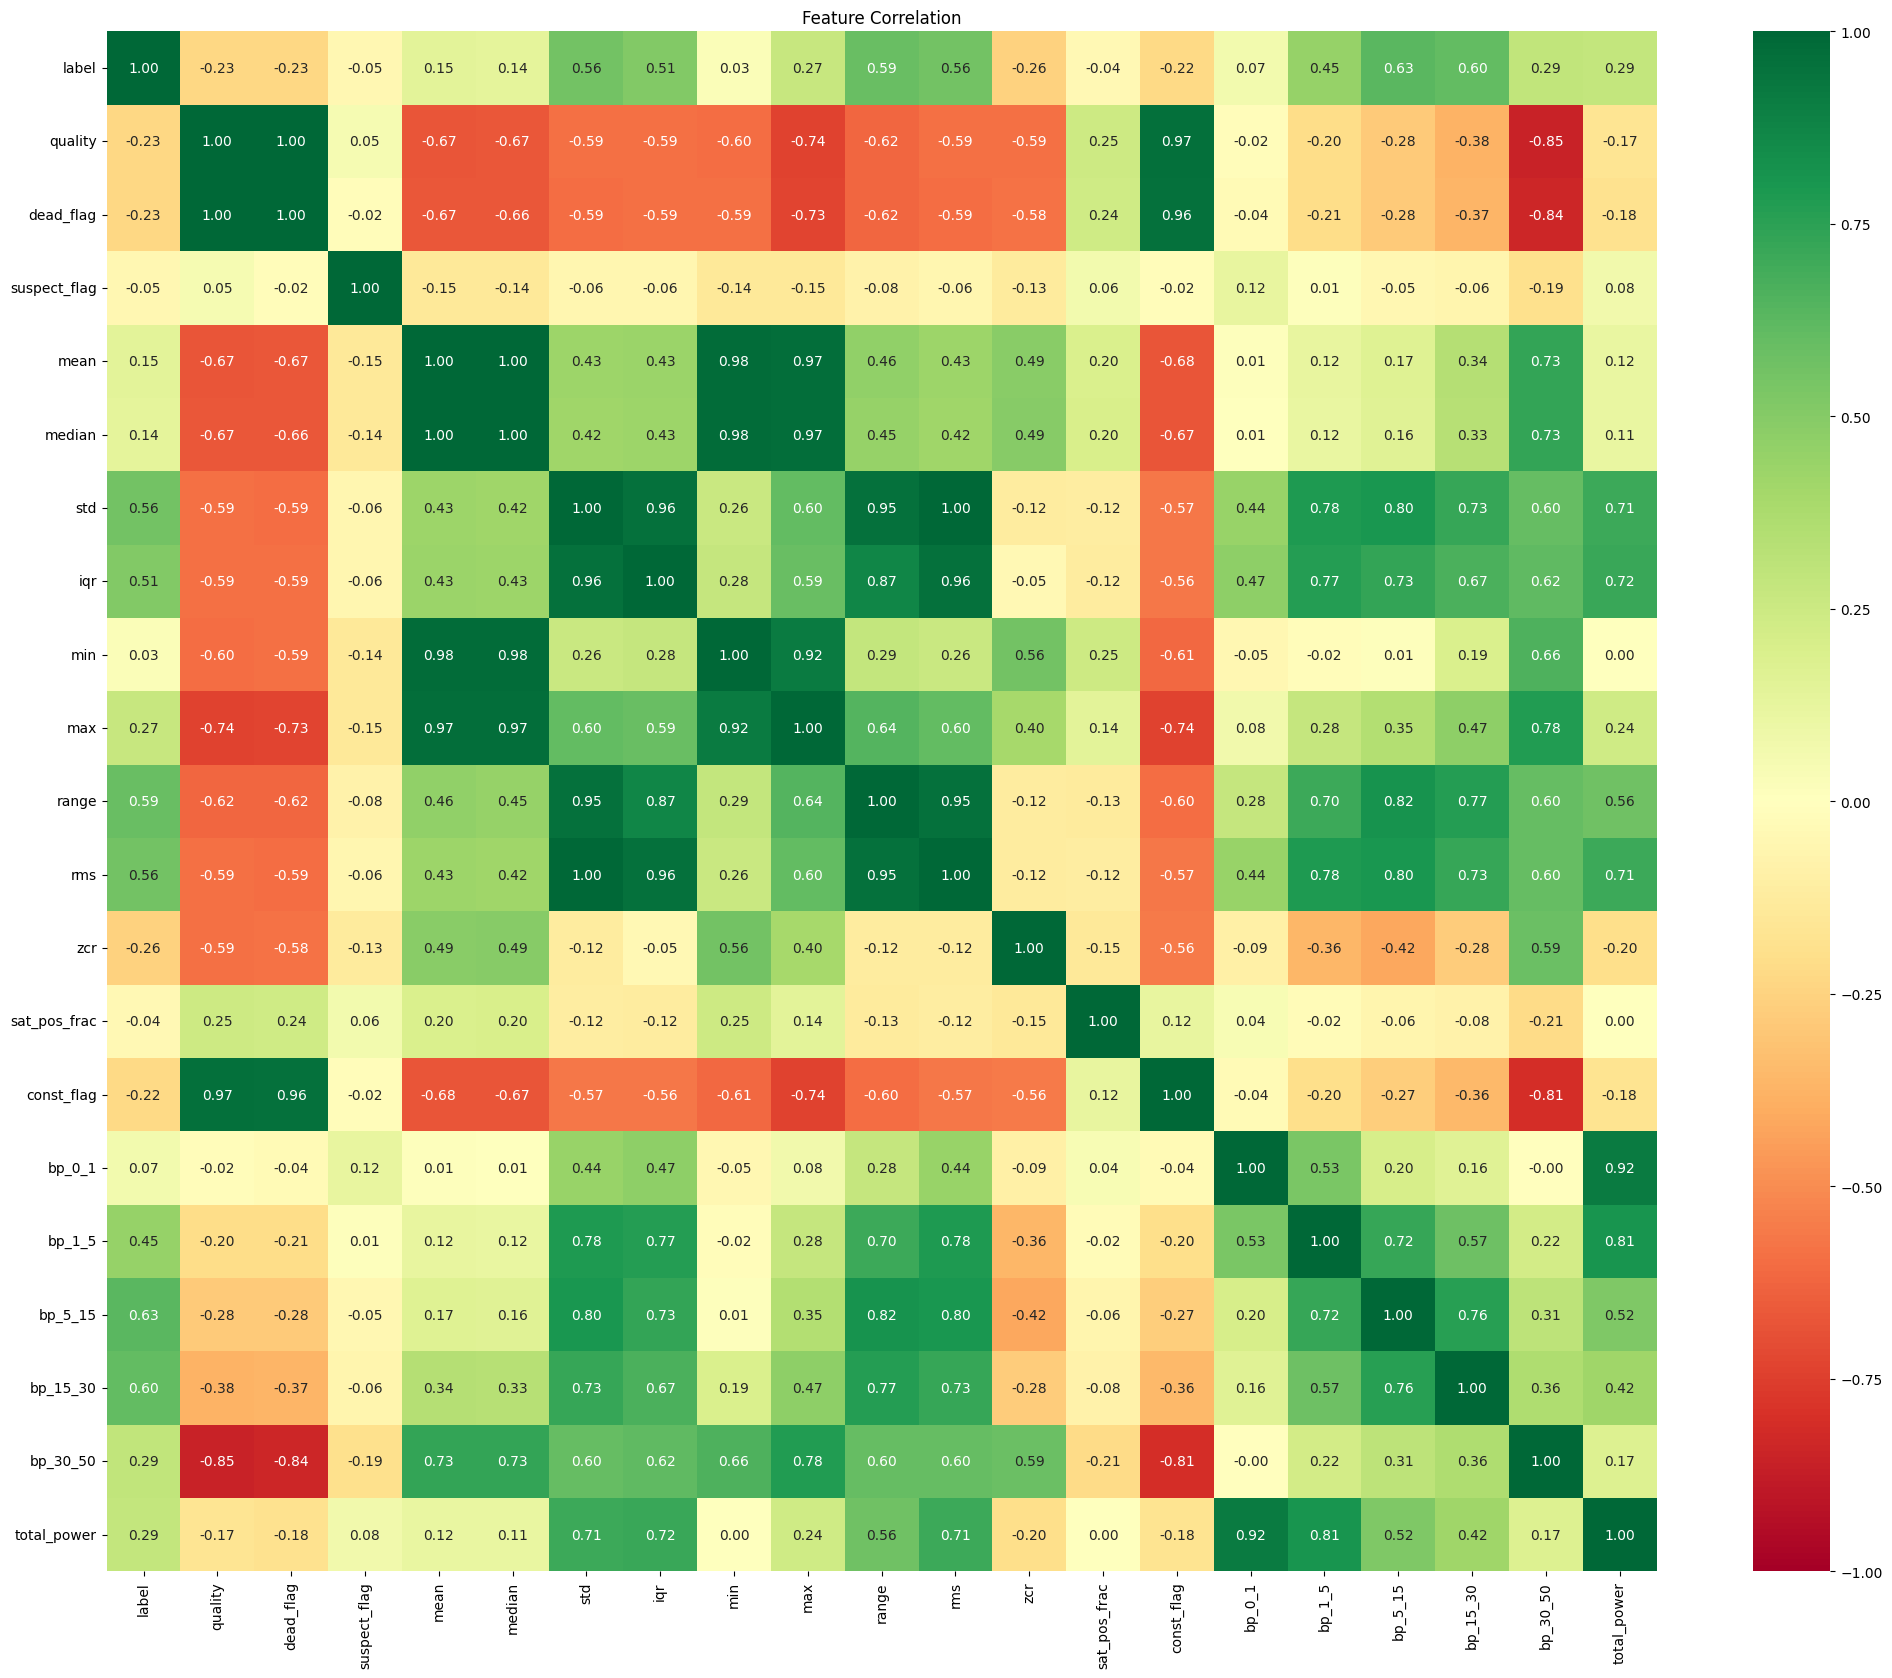

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def feat_corr(input_df):
    corr = input_df.corr()
    plt.figure(figsize=(25,20))
    #plot heat map
    g=sns.heatmap(corr, annot=True, cmap="RdYlGn", vmin=-1, vmax=1, fmt=".2f")
    plt.title('Feature Correlation')
    
    return plt.show()

feat_corr(df_em)


std, iqr, max, range, rms, zcr, const_flag, bp_1_5, bp_5_15, bp_15_30, bp_30_50, total_power

In [8]:
selected_cols = ["label", 
                "std", 
                "iqr",
                "max",
                "range", 
                "rms", 
                "zcr", 
                "const_flag", 
                "bp_1_5", 
                "bp_5_15", 
                "bp_15_30", 
                "bp_30_50", 
                "total_power"]

df_em_features = df_em[selected_cols].copy()